# Image Annulus Computation Methodology
### Computes the bounds of the annulus and number of rays for a given lens system using the following methodology:

#### Computing the ray shooting region:

1. Use analytic equations to find the size of the central caustic for each binary configuration (https://arxiv.org/pdf/astro-ph/0505363, Equations 8-10).
$$
    \xi_{c, 0} = \pm \dfrac{q}{(1 \pm s)(1 \pm s^{-1})}
$$
$$
    \eta_{c, 0} = \pm \dfrac{2q|\sin^3{\phi_c}|}{(s + s^{-1} - 2\cos{\phi_c})^2}
$$
$$
    \cos{\phi_c} = \dfrac{3}{4}(s + s^{-1})\left(1 - \sqrt{1 - \dfrac{32}{9}(s + s^{-1})^{-2}}\right)
$$

2. Assign size of caustic as the maximum distance from origin to caustic cusp.

3. Determine maximum and minimum sizes of sources in the magnification map. This is done by determining the source size 10 times larger than the size of the largest caustic and 100 times smaller than that largest source.

4. Find bounds of magnification map by ensuring a width of at least one source diameter can fit between farthest cusp of caustic and edge of magnification map.

5. If $s > 1 + 1.5q^{1/3}$:
    1. Use the corner of the magnification map (x1.1 for padding) to define a ring of source positions.
    2. Find the corresponding major and minor image positions for this ring by solving the lens equation.
    3. Use the average radii for both the major and minor image positions to define the annulus bounds.

6. If $s < 1 + 1.5q^{1/3}$:
    1. Use the corner of the magnification map (x1.1 for padding) to define a single source position.
    2. Find the corresponding image positions for this source by using the single lens image:
        $$
            y_{\pm} = \pm \dfrac{1}{2}(\sqrt{u^2+4} \pm u)
        $$
    3. Use these two image positions to determine the bounds of the annulus.

#### Finding the required number of rays to shoot in both r and theta to get a Poisson error ($\delta$) of less than 0.001:

1. Calculate the single lens magnification at the corner of the magnification map:
    $$
        A = \dfrac{u^2 + 2}{u\sqrt{u^2 + 4}}
    $$

2. Calculate the ray density within the annulus:
    $$
        \sigma_{rays} = \dfrac{1}{A dx^2 \delta^2}
    $$

3. Find the area of the annulus:
    $$
        Area = \pi(r_{out}^2 - r_{in}^2)
    $$

4. Calculate the total number of rays required:
    $$
        N_{rays} = Area \cdot \sigma_{rays}
    $$

5. Use a ratio of 1:4 for theta:r to find the number of rays required in each direction:
    $$
        N_r = \sqrt{\dfrac{N_{rays}}{4}}
    $$
    $$
        N_{\theta} = 4 N_r
    $$

In [304]:
# Importing crap
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Initializing VBMicrolensing and creating custom function to find image positions using MulensModel solution of the lens equation.

In [305]:
VBM = VBMicrolensing.VBMicrolensing() # Instance to VBMicroLensing
import MulensModel as mm

class MyBinaryLens(mm.BinaryLensPointSourceWM95Magnification):
    """Custom BinaryLens class potentially for modifications or extensions."""
    def __init__(self, q, s):
        # Initialize the parent MulensModel.BinaryLens
        self.s = s

        parameters = {'q': q, 's': s, 't_0': 0, 't_E': 1, 'u_0': 0.006, 'alpha': 0}
        model_params = mm.ModelParameters(parameters=parameters)

        traj = mm.Trajectory(times=0, parameters=model_params)

        super().__init__(trajectory=traj)

    def get_n_images(self, x, y):
        """
        Calculates the positions of images for a source at position (x, y).
        Relies on the _verify_polynomial_roots method from the parent class.
        """
        # The length of the list of roots corresponds to the number of images
        magnification = self._get_1_magnification(x, y, separation=self.s)

        # Getting image positions with the origin at the planet (0, 0)
        results = np.array(self._verify_polynomial_roots())

        # Shifting image positions to have origin at star
        for i in range(len(results)):
            results[i] += self.s + 0.0j

        return magnification, results

Function to compute the ray shooting region

In [457]:
def ang_width_thickness_calculator(lens_att: list | np.ndarray, source_radius: float, cm_offset: str | tuple | list = [0, 0], cm_translation: tuple | list = [0, 0]):
    '''
    Calculates the angular width of sampling region and thickness of shooting region using Equations 8-10 in https://arxiv.org/pdf/astro-ph/0505363.

    Parameters
    ----------
    lens_att : list
        Passed through via passed_params dict
    source_radius : float
        Radius of source in units of Einstein radius
    cm_offset : str or tuple or list, optional
        Center of mass offset to be added to caustic positions. If 'auto', then the center of mass of each star-planet combination is used. Default is [0, 0]
    cm_translation : tuple or list, optional
        Center of mass translation to be applied to caustic positions. Default is [0, 0]

    Returns
    -------
    ang_width : float
        Angular width of ray sampling region
    thickness : float
        Thickness of annulus shooting region
    (y_plus, y_minus) : tuple
        Major and minor image positions
    points : Lx4x2 NDArray
        Locations of caustic cusps in the inertial frame
    '''
    lens_att = np.array(lens_att)
    
    # Number of lens objects
    L = np.shape(lens_att)[0]

    # If radii
    if np.shape(lens_att)[1] == 4:
        mass_ind = 3
    else:
        mass_ind = 2

    # Initializing maximum distance from origin list
    max_dist_rot = []
    max_dist = []
    points = np.zeros(shape=(L-1, 4, 2))

    caustic_sizes = []

    # Initializing padding
    # padding = 2

    # Calculating the center of masses of each individual star-planet combination
    lens_CMs_rot = np.zeros(shape=(L-1, 2))
    
    for i, lens in enumerate(lens_att[1:]):
        two_lenses = np.array([lens_att[0], lens])

        # Finding which index the bigger mass was passed in (primary lens)
        big_mass = np.where(two_lenses[:, mass_ind] == np.max(two_lenses[:, mass_ind]))[0][0]

        # Secondary lens
        small_mass = int(not big_mass)

        # Defining unit source vector
        uhat = [1, 0]

        # Defining unit binary axis vector (from primary to secondary lens)
        v = [two_lenses[small_mass, 0] - two_lenses[big_mass, 0], two_lenses[small_mass, 1] - two_lenses[big_mass, 1]]
        vhat = v / np.linalg.norm(v)

        # Finding counterclockwise angle between binary axis and source trajectory (alpha)
        if vhat[0] > 0 and vhat[1] > 0:
            alpha = np.arctan(vhat[1]/vhat[0])
        elif vhat[0] < 0 and vhat[1] > 0:
            alpha = np.pi + np.arctan(vhat[1]/vhat[0])
        elif vhat[0] < 0 and vhat[1] < 0:
            alpha = np.pi + np.arctan(vhat[1]/vhat[0])
        elif vhat[0] > 0 and vhat[1] < 0:
            alpha = np.arctan(vhat[1]/vhat[0])
        elif vhat[0] > 0 and vhat[1] == 0:
            alpha = 0
        elif vhat[0] == 0 and vhat[1] > 0:
            alpha = np.pi/2
        elif vhat[0] < 0 and vhat[1] == 0:
            alpha = np.pi
        elif vhat[0] == 0 and vhat[1] < 0:
            alpha = -np.pi/2

        # Calculating distance between lenses (s)
        s = np.linalg.norm(v)

        # Calculating mass ratio between lenses (q)
        q = two_lenses[small_mass, mass_ind] / two_lenses[big_mass, mass_ind]

        # Calculating center of mass in binary axis
        lens_CMs_rot[i, 0] = q*s / (1 + q)

        # Creating rotation matrix
        cos, sin = np.cos(alpha), np.sin(alpha)
        Rot = np.array([[cos, -sin], [sin, cos]])

        # Finding cos(phi_c) - Equation 10
        cos_phi_c = 3/4 * (s + s**-1) * (1 - np.sqrt(1 - 32/9*(s + s**-1)**-2))

        # Finding phi_c through arccos
        phi_c = np.arccos(cos_phi_c)

        if cm_offset == 'auto':
            cm_offset = lens_CMs_rot[i]

        # Finding positive x and negative x positions - Equation 8
        x_pos_rot = q / ((1 + s)*(1 + s**-1)) - lens_CMs_rot[i, 0]
        x_neg_rot = -q / ((1 - s)*(1 - s**-1)) - lens_CMs_rot[i, 0]

        # Finding positive y and negative y positions - Equation 9
        y_pos_rot = (2*q * np.abs(np.sin(phi_c)**3)) / (s + s**-1 - 2*cos_phi_c)**2 - lens_CMs_rot[i, 1]
        y_neg_rot = -(2*q * np.abs(np.sin(phi_c)**3)) / (s + s**-1 - 2*cos_phi_c)**2 - lens_CMs_rot[i, 1]

        # Storing the maximum distance from the origin of the caustic
        max_dist_rot.append(np.max(np.abs(np.array([x_pos_rot, x_neg_rot, y_pos_rot, y_neg_rot]))))

        # Rotating bounding points back from binary axis to inertial axis
        x_pos = np.dot(Rot, np.array([x_pos_rot, 0])) + cm_offset - cm_translation
        x_neg = np.dot(Rot, np.array([x_neg_rot, 0])) + cm_offset - cm_translation

        y_pos = np.dot(Rot, np.array([0, y_pos_rot])) # + cm_offset - cm_translation
        y_neg = np.dot(Rot, np.array([0, y_neg_rot])) # + cm_offset - cm_translation

        # Finding maximum distance from the origin and storing it
        points[i, :, :] = np.array([x_pos, x_neg, y_pos, y_neg])
        max_dist.append(np.max(np.abs(points[i, :, :])))

        width = abs(x_pos_rot - x_neg_rot)
        height = abs(y_pos_rot - y_neg_rot)

        print(width, height)

        caustic_sizes.append(max(width, height))

    # Finding the maximum distance of a cusp from the origin among all caustics
    max_cusp_distance = np.max(max_dist)

    # Finding maximum caustic size
    max_caustic_size = np.max(caustic_sizes)

    # Finding maximum source radius
    max_source_radius = (10 * max_caustic_size) / 2
    min_source_radius = max_source_radius / 100

    # Adding source diameter as padding
    ang_width_source = 2 * (max_cusp_distance + 2.1*max_source_radius)

    # Angular width regardless of source size
    ang_width_nosource = 4 * max_cusp_distance

    # Choose largest width:
    ang_width = max(ang_width_source, ang_width_nosource)

    # Adjusting angular width to test larger source sizes
    ang_width *= 2.0

    # Finding the maximum distance from the origin of magnification map
    u = 1.05 * ang_width / np.sqrt(2)
    
    # Finding major and minor image positions (y+ > 0 and y- < 0)
    y_plus = 0.5 * (u + np.sqrt(u**2 + 4))
    y_minus = 0.5 * (u - np.sqrt(u**2 + 4))

    # Calculating thickness of annulus
    thickness = y_plus + y_minus

    return ang_width, thickness, (y_plus, y_minus), points, (max_source_radius, min_source_radius)

Function to create number of rays in annulus

In [458]:
def num_ray_calculator(pixels: int, ang_width: float, delta: float, y_plus: float, y_minus: float, r_theta_ratio: int | float = 4):
    # Analytic single lens magnification equation
    A = lambda u: (u**2 + 2) / (u * np.sqrt(u**2 + 4))

    # Distance of corner of map
    u = 1.05 * ang_width / np.sqrt(2)
    
    # Width of pixel
    dx = ang_width / (pixels - 1)

    # Area of annulus
    a_ann = (np.pi * (y_plus**2 - y_minus**2))

    # Ray density in annulus
    n_image = 1 / (A(u) * dx**2 * delta**2)

    # Total number of rays
    N_rays = n_image * a_ann

    # Number of rays in theta
    num_theta = int(np.ceil(np.sqrt(N_rays / r_theta_ratio)))

    # Number of rays in r
    num_r = int(np.ceil(r_theta_ratio * num_theta))

    return num_r, num_theta


Function to find memory of class objects

In [459]:
import sys
from types import ModuleType, FunctionType

# A helper to avoid double-counting objects
def get_size(obj, seen=None):
    """Recursively finds the size of objects in bytes."""
    size = sys.getsizeof(obj)
    # if seen is None:
    #     seen = set()
    # obj_id = id(obj)
    # if obj_id in seen:
    #     return 0
    # seen.add(obj_id)

    if isinstance(obj, dict):
        size += sum([get_size(v, seen) + get_size(k, seen) for k, v in obj.items()])
    elif isinstance(obj, np.ndarray):
        size += obj.nbytes
    # elif hasattr(obj, "__dict__"):
    #     size += get_size(vars(obj), seen)
    # elif hasattr(obj, "__iter__") and not isinstance(obj, (str, bytes, bytearray)):
    #     size += sum([get_size(i, seen) for i in obj])
    return size


def class_size(obj):
    """Iterates through all attributes of a class instance and reports sizes."""
    total = sys.getsizeof(obj)
    details = {}
    
    for attr_name in dir(obj):
        # Skip dunder methods and functions
        if attr_name.startswith("__") and attr_name.endswith("__"):
            continue

        try:
            attr = getattr(obj, attr_name)
        except AttributeError as e:
            print(attr_name)
            continue

        # if isinstance(attr, (ModuleType, FunctionType)):
        #     continue

        size = get_size(attr)
        details[attr_name] = size
        total += size
    
    return total, details

Testing with a simple binary lens system

In [460]:
s_str = '1/0.7'
s = eval(s_str)
q = 1e-3
source_radius = 1e-3

lens_att = [
    [0, 0, 1.0],     # Star at origin with mass 1.0
    [s, 0, q]        # Planet at (s, 0) with mass ratio q
]

lens_att = np.array(lens_att)

center_of_mass = np.average(lens_att[:, :2], axis=0, weights=lens_att[:, 2])
center_of_magnification = np.array([q / ((1 + q) * (s + 1/s)), 0])

desired_offset = center_of_magnification

lens_att[:, :2] -= desired_offset

caustics = VBM.Caustics(s, q)
caustics = np.array(caustics, dtype=object)

# Calculating angular width and thickness of annulus
ang_width, single_thickness, (single_y_plus, single_y_minus), cusp_points, (max_source_radius, min_source_radius) = ang_width_thickness_calculator(lens_att, source_radius=source_radius, cm_offset='auto', cm_translation=desired_offset)

print(f'Angular width of sampling region: {ang_width}')
print(f'Major image position (y+): {single_y_plus}')
print(f'Minor image position (y-): {single_y_minus}')

print(f'Maximum recommended source radius: {max_source_radius}')
print(f'Minimum recommended source radius: {min_source_radius}')

0.007535563244905804 0.0031848724923912446
Angular width of sampling region: 0.345727450083596
Major image position (y+): 1.136547316616518
Minor image position (y-): -0.8798577810002515
Maximum recommended source radius: 0.03767781622452902
Minimum recommended source radius: 0.00037677816224529026


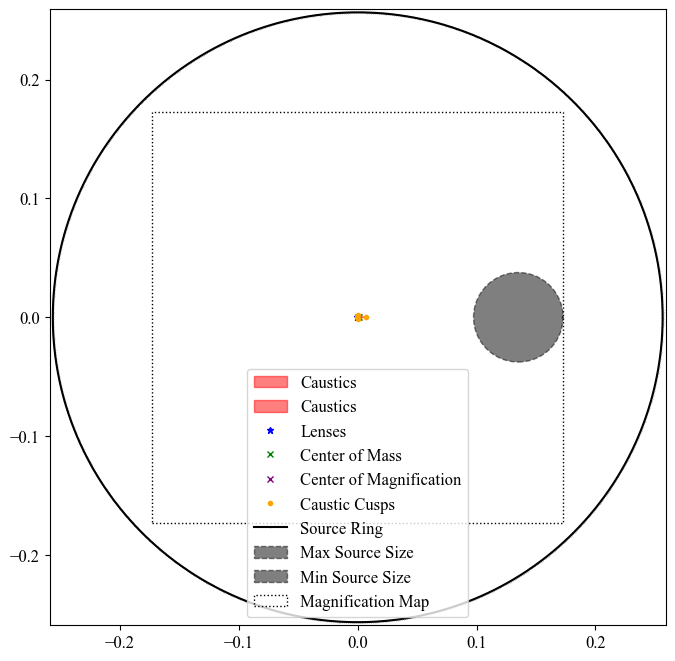

In [461]:
fig = plt.figure()
ax = fig.add_subplot()

for caustic in caustics:
    x = caustic[0] + center_of_mass[0] - desired_offset[0]
    y = caustic[1] + center_of_mass[1] - desired_offset[1]
    points = np.array([x, y]).T
    
    fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Caustics', facecolor='red', alpha=0.5)
    ax.add_patch(fpr)

ax.plot(lens_att[:, 0] - desired_offset[0], lens_att[:, 1] - desired_offset[1], color='blue', marker='*', linestyle='None', markersize=5, label='Lenses')
ax.plot(center_of_mass[0] - desired_offset[0], center_of_mass[1] - desired_offset[1], color='green', marker='x', linestyle='None', markersize=5, label='Center of Mass')
ax.plot(center_of_magnification[0] - desired_offset[0], center_of_magnification[1] - desired_offset[1], color='purple', marker='x', linestyle='None', markersize=5, label='Center of Magnification')

for point_collection in cusp_points:
    ax.plot(point_collection[:, 0], point_collection[:, 1], color='orange', marker='o', linestyle='None', markersize=3, label='Caustic Cusps')

max_source_patch = patches.Circle((ang_width/2 - max_source_radius, 0), max_source_radius, fill=True, edgecolor='black', facecolor='black', alpha=0.5, linestyle='--', label='Max Source Size')
min_source_patch = patches.Circle((ang_width/2 - min_source_radius, 0), min_source_radius, fill=True, edgecolor='black', facecolor='black', alpha=0.5, linestyle='--', label='Min Source Size')
map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', label='Magnification Map')

r = 1.05 * ang_width / np.sqrt(2)
thetas = np.linspace(0, 2*np.pi, 1000, endpoint=False)
xs = r * np.cos(thetas)
ys = r * np.sin(thetas)

ax.plot(xs, ys, color='black', marker='.', linestyle=None, markersize=0.2, label='Source Ring')

new_ang_width = 1.5*ang_width

ax.set_xlim(-new_ang_width/2, new_ang_width/2)
ax.set_ylim(-new_ang_width/2, new_ang_width/2)
ax.set_aspect('equal')

ax.add_patch(max_source_patch)
ax.add_patch(min_source_patch)
ax.add_patch(map_patch)

ax.legend()

plt.show()

1. Choose a big map that you know is bigger than you need (biggest map you can that allows you to do a source that is at least 8 times bigger than the caustic)
2. See how much bigger the source needs to be than the caustic to see no deviations
3. Find the source radius relative to caustic size such that no deviations bigger than 1e-3
4. Choose that ratio for all systems and use that as the largest source (* largest caustic size)
5. Choose size of grid such that there is at least one source diameter between caustic and edge of grid
6. Choose the pixel size such that the diameter of the **smallest** source is sampled by at least 100x100 pixels

- Start with 10 times width of caustic (might be overkill)
- Go down to 100 times less than that


NSF GRFP
- Firtst thing is writing code to make sure it works
- Explore sensitivity for three body systems with using magnification maps
- Expand to fitting of light curves
- Apply what I have learned to search for multiplanet and multiple moon systems as detected by Roman
- What should be expected from Roman as I start graduate school, multiple planet systems beyond snow line

Grad schools
Add places
- UCLA (not as good of a program as OSU, Erik Petigura)
- Hawaii
- Washington
- University of Colorado
- University of Chicago
- MIT, physics astro program (not too good)
- University of Maryland
- Johns Hopkins
- UT Austin
- Texas A&M not super good
- University of Michigan
- UC Santa Cruz (good exoplanet program)
- Penn State (small town, one of the best exoplanet programs)

4 reach schools, 4 safety schools, 10 target schools

(3000, 2)
(1000,)


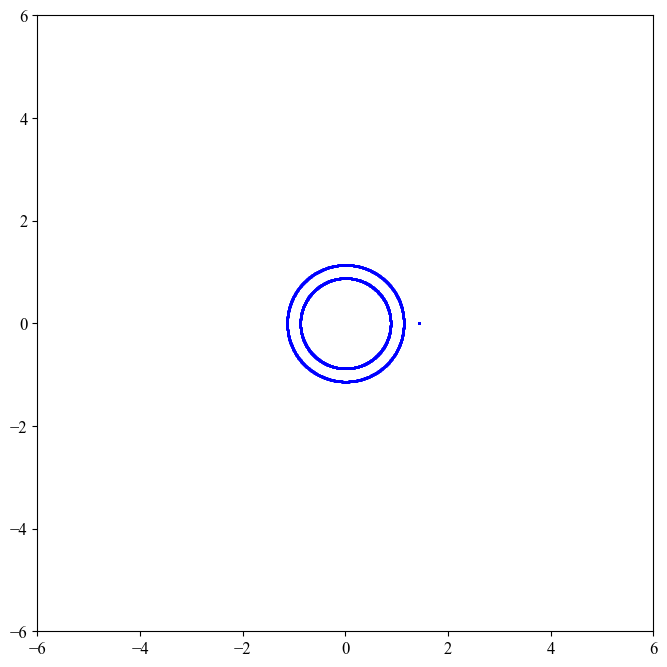

In [462]:
model = MyBinaryLens(q=q, s=s)
all_points = []
ring_magnifications = []

for x, y in zip(xs, ys):
    magnification, image_positions = model.get_n_images(x - center_of_mass[0], y - center_of_mass[1])

    for image_position in image_positions:
        all_points.append([image_position.real, image_position.imag])

    ring_magnifications.append(magnification)

all_points = np.array(all_points)
ring_magnifications = np.array(ring_magnifications)
print(np.shape(all_points))
print(np.shape(ring_magnifications))

fig = plt.figure()
ax = fig.add_subplot()

ax.plot(all_points[:, 0], all_points[:, 1], color='b', marker='o', linestyle='None', markersize=1, label='All Points')

ax.set_aspect('equal')

view = 6

ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

plt.show()

In [463]:
def separate_circles(points, s, q):
    """
    Separate points into three circles.
    
    Parameters
    ----------
    points : np.ndarray
        Array of shape (N, 2) with all points.
    s : float
        x-coordinate of the off-center circle centroid (y = 0).
    q : float
        Squared radius of the off-center circle.
    
    Returns
    -------
    off_center : np.ndarray
        Points belonging to the off-center circle.
    small_origin : np.ndarray
        Points belonging to the smaller origin-centered circle (avg radius < 1).
    large_origin : np.ndarray
        Points belonging to the larger origin-centered circle (avg radius > 1).
    """
    # Off-center circle parameters
    off_center = np.array([s, 0])
    off_radius = np.sqrt(q)

    # Distance of each point to off-center centroid
    d_off = np.linalg.norm(points - off_center, axis=1)

    # Assign off-center points if their radius is close to expected
    mask_off = np.abs(d_off - off_radius) < off_radius
    off_circle = points[mask_off]

    # Remaining points are origin-centered
    origin_points = points[~mask_off]

    # Compute radii of all origin-centered points
    r_origin = np.linalg.norm(origin_points, axis=1)

    # Split into two groups: below 1 and above 1
    small_mask = r_origin < 1
    small_origin = origin_points[small_mask]
    large_origin = origin_points[~small_mask]

    # (Optional) sanity check: swap if mislabeled
    if np.mean(np.linalg.norm(small_origin, axis=1)) > np.mean(np.linalg.norm(large_origin, axis=1)):
        small_origin, large_origin = large_origin, small_origin

    return off_circle, small_origin, large_origin

(1000, 2) (1000, 2) (1000, 2)


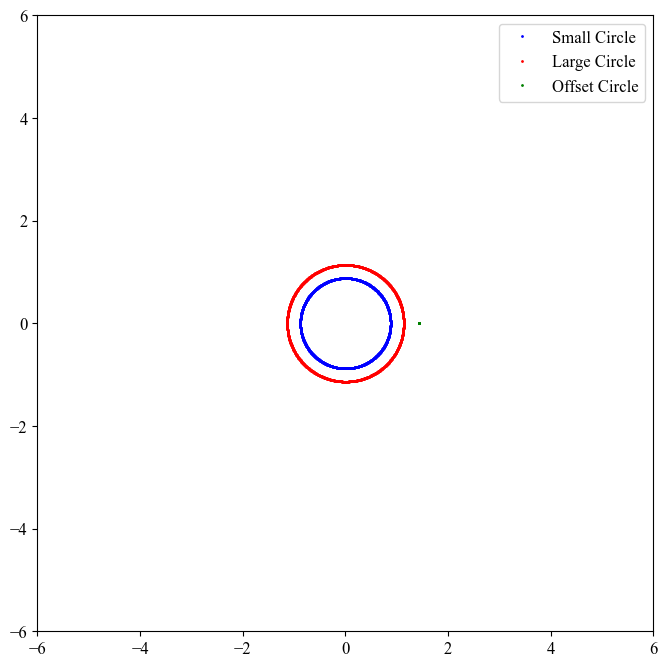

In [464]:
offset_circle, small_circle, large_circle = separate_circles(all_points, s, q)
print(np.shape(small_circle), np.shape(large_circle), np.shape(offset_circle))
# print(large_circle)

fig = plt.figure()
ax = fig.add_subplot()

ax.plot(small_circle[:, 0], small_circle[:, 1], color='b', marker='o', linestyle='None', markersize=1, label='Small Circle')
ax.plot(large_circle[:, 0], large_circle[:, 1], color='r', marker='o', linestyle='None', markersize=1, label='Large Circle')
ax.plot(offset_circle[:, 0], offset_circle[:, 1], color='g', marker='o', linestyle='None', markersize=1, label='Offset Circle')

ax.set_aspect('equal')

view = 6
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.legend()

plt.show()

y+ = 1.13605536519944, y- = 0.8793615814347195
Percent error = 8.21e-01 %


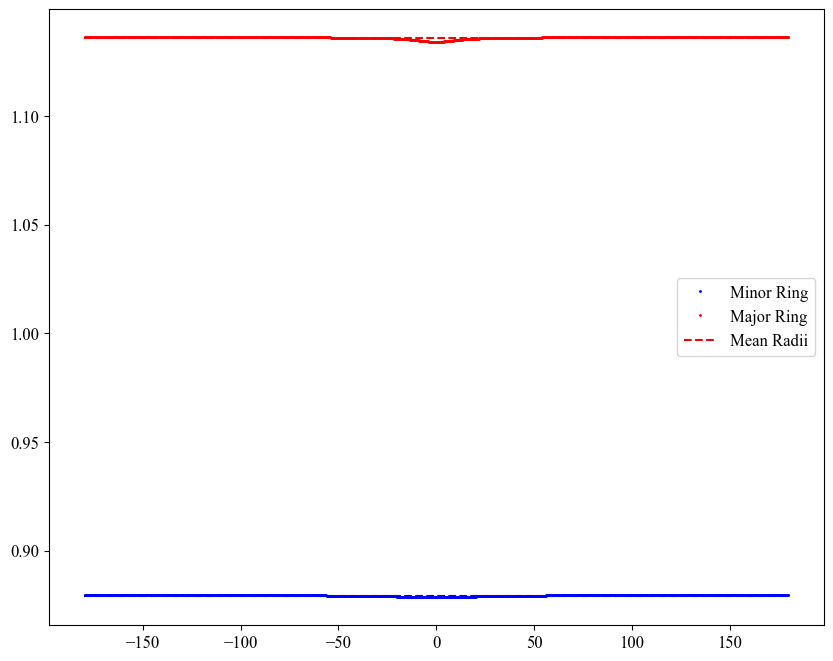

In [465]:
small_rs = np.sqrt(small_circle[:, 0]**2 + small_circle[:, 1]**2)
small_thetas = np.arctan2(small_circle[:, 1], small_circle[:, 0]) * 180 / np.pi

big_rs = np.sqrt(large_circle[:, 0]**2 + large_circle[:, 1]**2)
big_thetas = np.arctan2(large_circle[:, 1], large_circle[:, 0]) * 180 / np.pi

y_plus = np.mean(big_rs)
y_minus = np.mean(small_rs)

print(f'y+ = {y_plus}, y- = {y_minus}')
if s < 1:
    u = 1.1 * ang_width / np.sqrt(2)
    print(f'Expected y+ = {0.5 * (u + np.sqrt(u**2 + 4))}, Expected y- = {0.5 * (u - np.sqrt(u**2 + 4))}')

    print(f'Percent error y+ = {(np.abs(y_plus - 0.5 * (u + np.sqrt(u**2 + 4))) / (0.5 * (u + np.sqrt(u**2 + 4))) * 100):.2e} %')
    print(f'Percent error y- = {(np.abs(y_minus + 0.5 * (u - np.sqrt(u**2 + 4))) / (-0.5 * (u - np.sqrt(u**2 + 4))) * 100):.2e} %')

else:
    print(f'Percent error = {(np.abs(np.mean([y_plus, y_minus]) - np.sqrt(1 - q)) / np.sqrt(1 - q) * 100):.2e} %')

fig = plt.figure()
ax = fig.add_subplot()

ax.plot(small_thetas, small_rs, color='b', marker='o', linestyle='None', markersize=1, label='Minor Ring')
ax.plot(big_thetas, big_rs, color='r', marker='o', linestyle='None', markersize=1, label='Major Ring')

ax.hlines([y_plus, y_minus], xmin=-180, xmax=180, colors=['r', 'b'], linestyles='--', label='Mean Radii')

ax.legend()

plt.show()

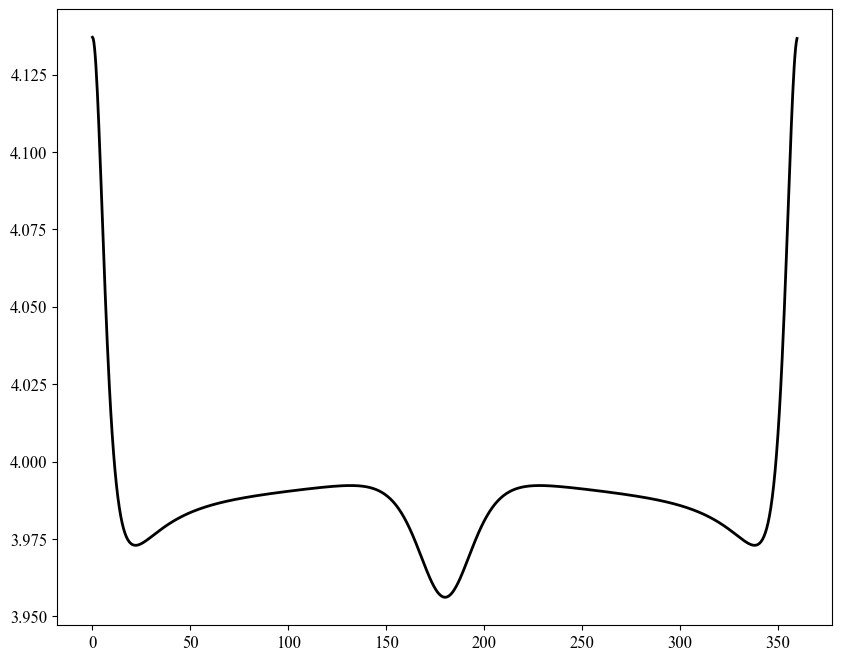

In [466]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(thetas * 180/np.pi, ring_magnifications, linewidth=2, color='black')

plt.show()

In [467]:
num_pixels_in_source = 10
ang_res = min_source_radius*2 / num_pixels_in_source

pixels = int(ang_width / ang_res) + 1
print(f'Pixels: {pixels}, Angular Resolution: {ang_res}')

delta = 0.01
r_theta_ratio = 4

Pixels: 4588, Angular Resolution: 7.535563244905805e-05


Determining number of rays to shoot in annulus

In [468]:
# Maximum magnification
A = np.min(ring_magnifications)

# Width of pixel
dx = ang_width / (pixels - 1)

# Area of annulus
a_ann = np.pi * (y_plus**2 - y_minus**2)

# Ray density in annulus
n_image = 1 / (A * dx**2 * delta**2)

# Total number of rays
N_rays = n_image * a_ann

# Number of rays in theta
num_theta = int(np.ceil(np.sqrt(N_rays / r_theta_ratio)))

# Number of rays in r
num_r = int(np.ceil(r_theta_ratio * num_theta))

print(f'Number of rays in r: {num_r}, Number of rays in theta: {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')

Number of rays in r: 1700804, Number of rays in theta: 425201
Total number of rays: 7.232e+11


In [469]:
binary_lens_parameters = {
    'pixels': 1000,
    'ang_width': ang_width,
    'thickness': y_plus - y_minus,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'lens_att': lens_att.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim = IRSC.IRSCaustics(annulus_param_dict=binary_lens_parameters)
magnifications = sim.series_calculate(cm_offset='auto', annulus_offset=desired_offset)

100%|██████████| 500/500 [00:04<00:00, 119.12it/s]

---------------------
Total time: 4.201 seconds


In [470]:
single_lens_parameters = {
    'pixels': 1000,
    'ang_width': ang_width,
    'thickness': single_thickness,
    'y_plus': single_y_plus,
    'y_minus': single_y_minus,
    'lens_att': np.array([[0, 0, 1]]).tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

single_sim = IRSC.IRSCaustics(annulus_param_dict=single_lens_parameters)
magnifications = single_sim.series_calculate(cm_offset='auto')

100%|██████████| 500/500 [00:03<00:00, 145.62it/s]

---------------------
Total time: 3.437 seconds


[[-4.69329328e-04  0.00000000e+00  1.00000000e+00]
 [ 1.42810210e+00  0.00000000e+00  1.00000000e-03]]
Plotting magnification map: 0.02 seconds
[[4.07928134 3.80732925 4.21525739 ... 3.9433053  4.07928134 4.21525739]
 [4.21525739 4.21525739 3.80732925 ... 4.35123343 4.21525739 4.07928134]
 [4.21525739 4.21525739 4.21525739 ... 4.21525739 3.9433053  4.35123343]
 ...
 [4.21525739 4.21525739 4.21525739 ... 4.21525739 3.9433053  4.35123343]
 [4.21525739 4.21525739 3.80732925 ... 4.35123343 4.21525739 4.07928134]
 [4.07928134 3.80732925 4.21525739 ... 3.9433053  4.07928134 4.21525739]]


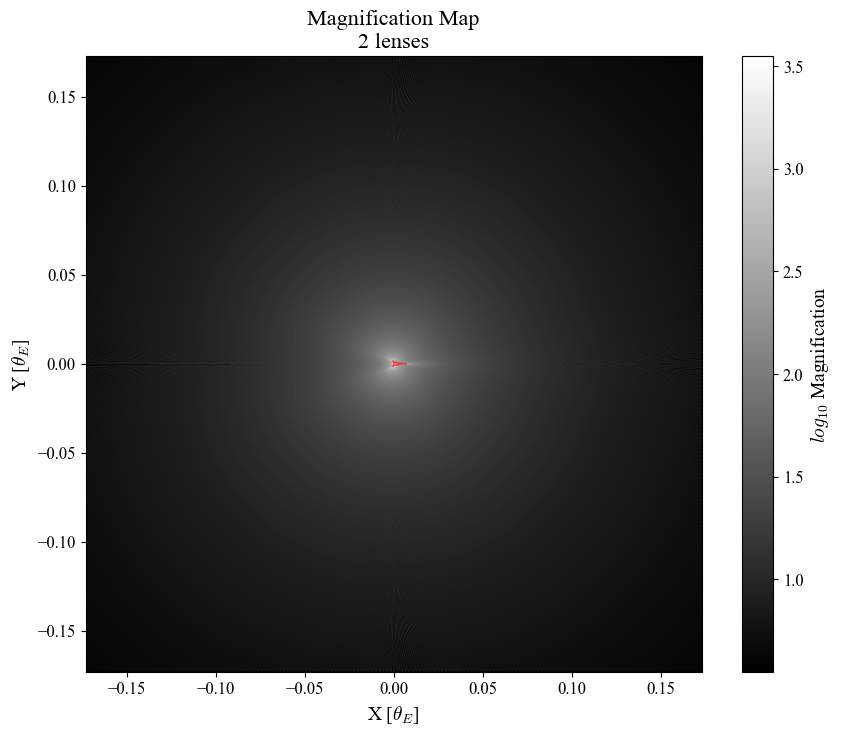

In [471]:
print(sim.lens_att)

sim.plot()

for caustic in caustics:
    x = caustic[0] + center_of_mass[0] - desired_offset[0]
    y = caustic[1] + center_of_mass[1] - desired_offset[1]
    points = np.array([x, y]).T
    
    fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Caustics', facecolor='red', alpha=0.5)
    sim.ax_c.add_patch(fpr)

map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', label='Magnification Map')

sim.ax_c.add_patch(map_patch)

print(sim.magnifications)

plt.show()

Plotting magnification map: 0.051 seconds
[[5.16953755 3.80913293 4.08121385 ... 4.08121385 3.80913293 5.16953755]
 [3.80913293 5.30557801 3.80913293 ... 3.80913293 5.30557801 3.80913293]
 [4.08121385 3.80913293 5.16953755 ... 5.16953755 3.80913293 4.08121385]
 ...
 [4.08121385 3.80913293 5.16953755 ... 5.16953755 3.80913293 4.08121385]
 [3.80913293 5.30557801 3.80913293 ... 3.80913293 5.30557801 3.80913293]
 [5.16953755 3.80913293 4.08121385 ... 4.08121385 3.80913293 5.16953755]]


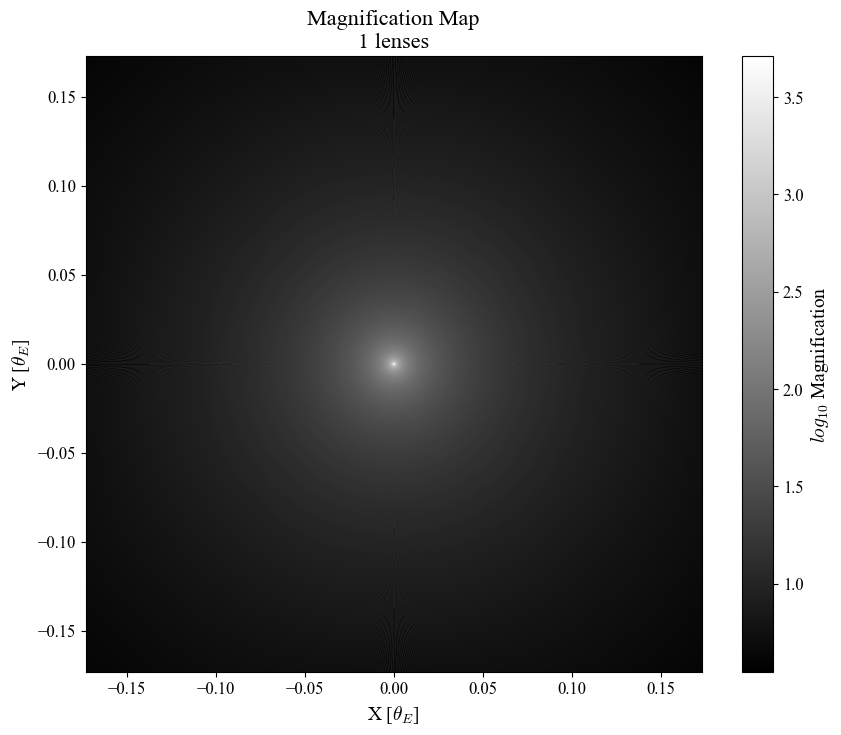

In [472]:
single_sim.plot()

print(single_sim.magnifications)

plt.show()

  0%|          | 0/435 [00:00<?, ?it/s]

100%|██████████| 435/435 [00:00<00:00, 2109.30it/s]


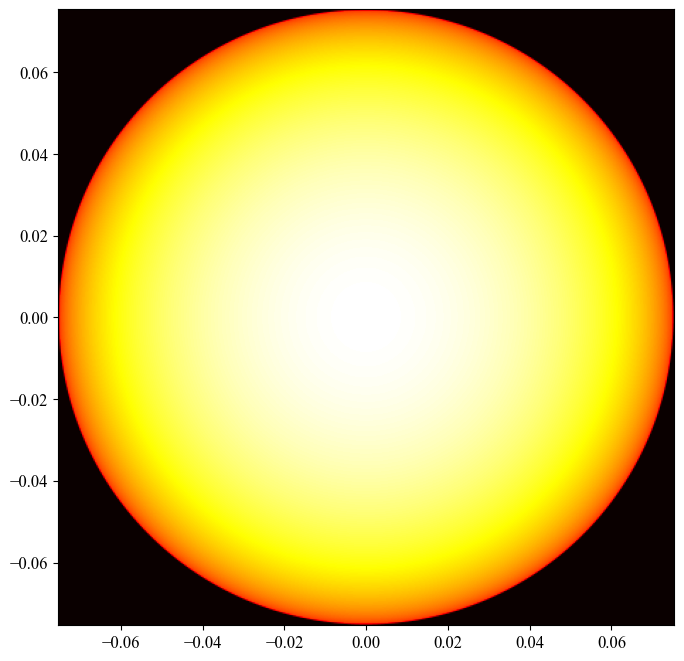

In [479]:
rad = 2*max_source_radius
source_profile = IRSF.IRSFunctions.source_profile(ang_res=sim.ang_res, rad=rad, profile_type='LD', LD=0.5, supersample=10)

fig = plt.figure()
ax = fig.add_subplot()
ax.imshow(source_profile, origin='lower', extent=[-rad, rad, -rad, rad], cmap='hot')
plt.show()

In [480]:
convolved_brightnesses = sim.convolve(source_profile=source_profile)
single_convolved_brightnesses = single_sim.convolve(source_profile=source_profile)

Convolving source profile with magnification map: 0.084 seconds
Convolving source profile with magnification map: 0.045 seconds


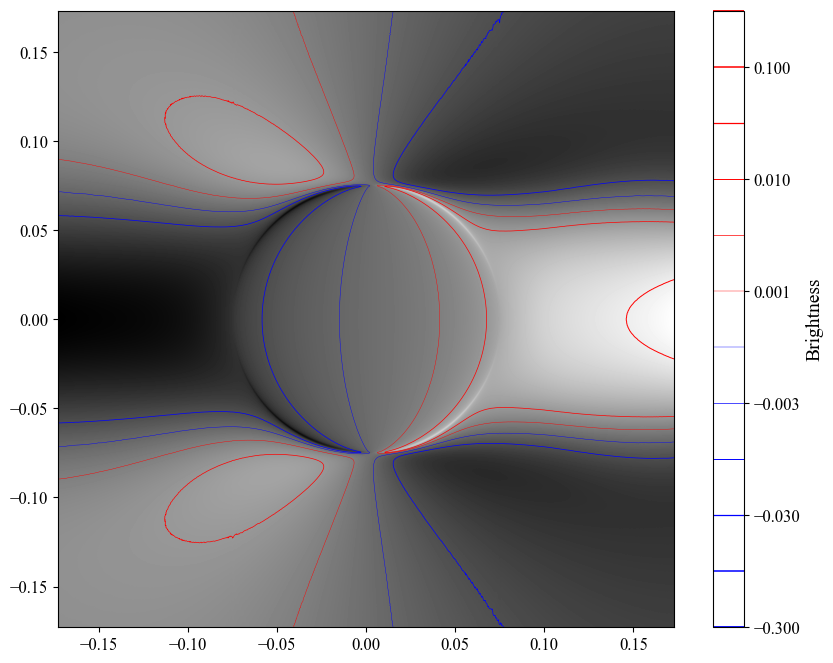

In [481]:
fractional_deviations = (convolved_brightnesses - single_convolved_brightnesses) / single_convolved_brightnesses

fig = plt.figure()
ax = fig.add_subplot()

ax.imshow(fractional_deviations, origin='lower', extent=[-sim.ang_width/2, sim.ang_width/2, -sim.ang_width/2, sim.ang_width/2], cmap='grey')
img = ax.contour(fractional_deviations, 
           levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
           colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
           linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
           extent=[-sim.ang_width/2, sim.ang_width/2, -sim.ang_width/2, sim.ang_width/2]
)

plt.colorbar(img, ax=ax, label='Brightness')

plt.show()

In [334]:
sim = IRSC.caustic_reader('../Unity/Simulations/Tests/source_size_deviations_2.pkl')
# sim = IRSC.caustic_reader('../Unity/Simulations/Binary_Collection/binary_1e-03_7.00e-01.pkl')
single_sim = IRSC.caustic_reader('../Unity/Simulations/Tests/source_size_deviations_single_2.pkl')
# single_sim = IRSC.caustic_reader('../Unity/Simulations/Single_Collection/single_1e-03_7.00e-01.pkl')

Plotting magnification map: 0.065 seconds
{'pixels': 2559, 'ang_width': 0.08149921923899223, 'thickness': 0.06052187258350594, 'y_plus': 1.0302202608142927, 'y_minus': 0.9696983882307868, 'lens_att': [[-0.0004693293283897312, 0.0, 1.0], [1.4281020992430389, 0.0, 0.001]], 'num_theta': 244245, 'num_r': 976980, 'ang_res': 3.186052354925419e-05, 'pixel_density': 31386.803749601553, 'dr': 6.194797696112807e-08, 'dtheta': 0.0014739298655038998, 'num_rays': 238622480100}
[[17.55833266 17.56775911 17.57561449 ... 17.18598792 17.15142427
  17.16556395]
 [17.57561449 17.58346986 17.57090126 ... 17.1812747  17.1498532
  17.1812747 ]
 [17.57404341 17.57718556 17.58818309 ... 17.187559   17.1624218
  17.17184825]
 ...
 [17.57404341 17.57718556 17.58818309 ... 17.187559   17.1624218
  17.17184825]
 [17.57561449 17.58346986 17.57090126 ... 17.1812747  17.1498532
  17.1812747 ]
 [17.55833266 17.56775911 17.57561449 ... 17.18598792 17.15142427
  17.16556395]]


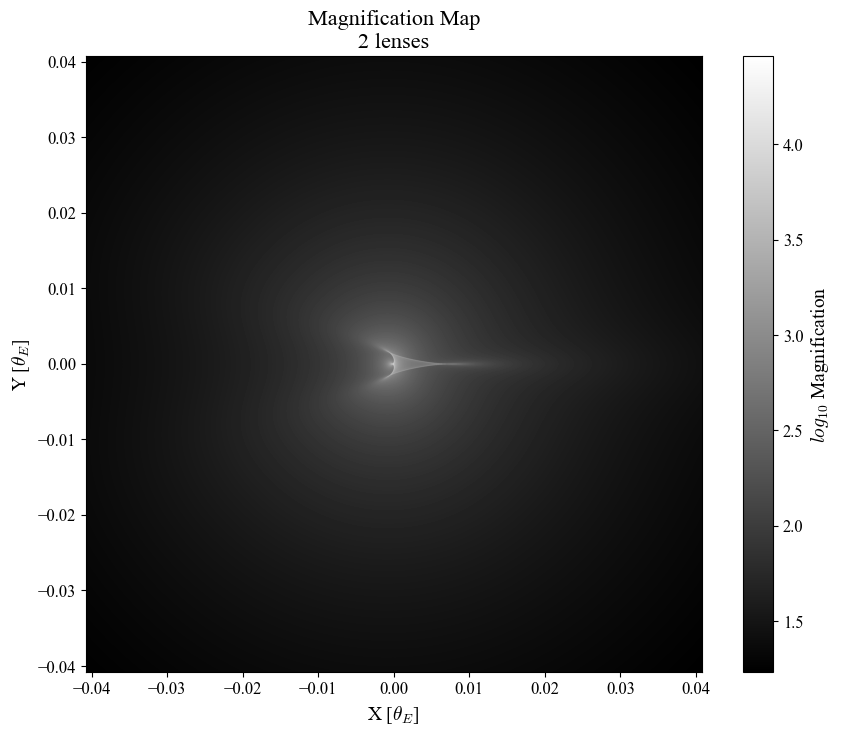

In [336]:
sim.plot()
print(sim.param_dict)

print(sim.magnifications)

plt.show()

Plotting magnification map: 0.119 seconds
{'pixels': 2559, 'ang_width': 0.08149921923899223, 'thickness': 0.06051008311456563, 'y_plus': 1.030712620637792, 'y_minus': 0.9702025375232263, 'lens_att': [[0, 0, 1]], 'num_theta': 244245, 'num_r': 976980, 'ang_res': 3.186052354925419e-05, 'pixel_density': 31386.803749601553, 'dr': 6.193590969157538e-08, 'dtheta': 0.0014739298655038998, 'num_rays': 238622480100}
[[17.36878714 17.3735018  17.38450266 ... 17.38450266 17.37193024
  17.36721559]
 [17.3735018  17.38135955 17.38450266 ... 17.38607421 17.379788
  17.37193024]
 [17.3766449  17.39236041 17.39078886 ... 17.39236041 17.39078886
  17.37821645]
 ...
 [17.3766449  17.39236041 17.39078886 ... 17.39236041 17.39078886
  17.37821645]
 [17.3735018  17.38135955 17.38450266 ... 17.38607421 17.379788
  17.37193024]
 [17.36878714 17.3735018  17.38450266 ... 17.38450266 17.37193024
  17.36721559]]


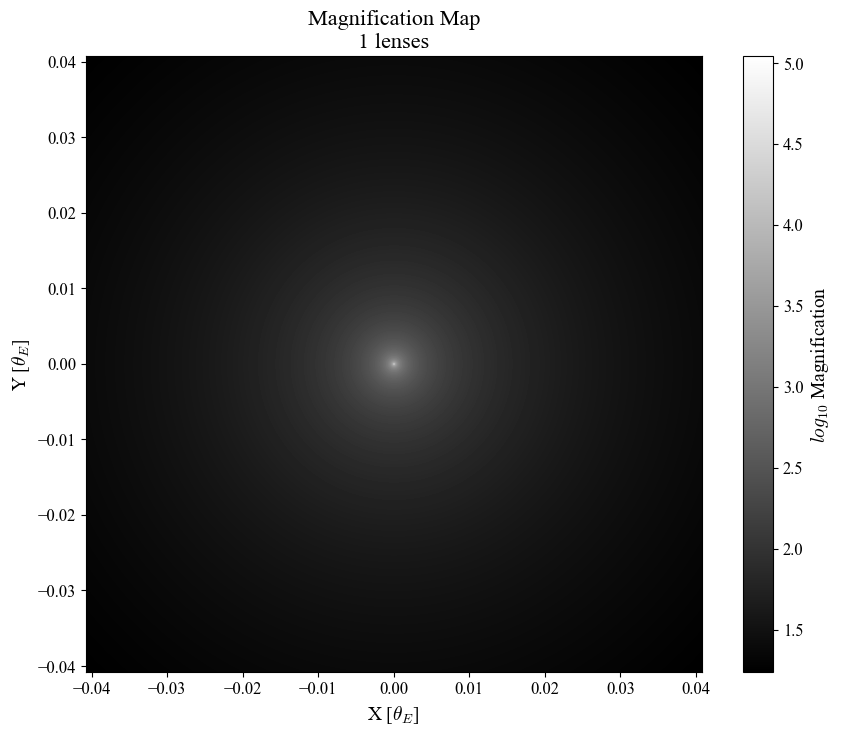

In [337]:
single_sim.plot()
print(single_sim.param_dict)

print(single_sim.magnifications)

plt.show()

100%|██████████| 1000/1000 [00:00<00:00, 1032.85it/s]


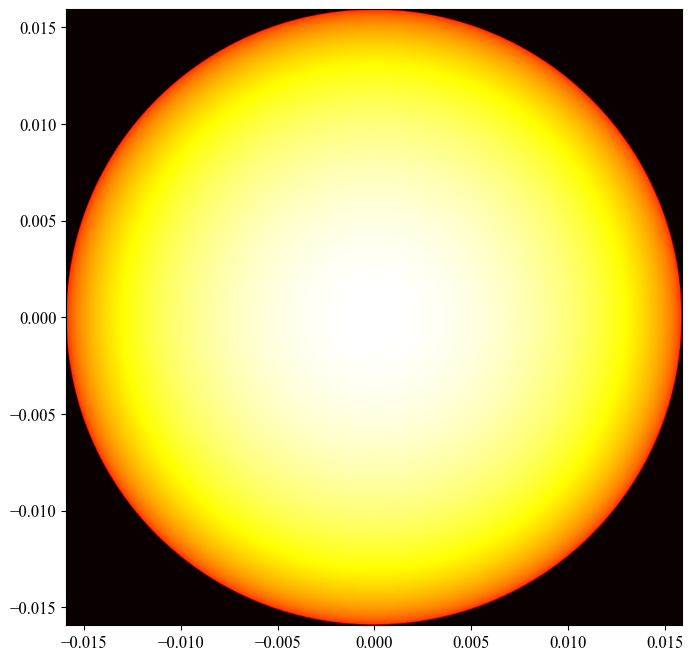

In [374]:
rad = max_source_radius
source_profile = IRSF.IRSFunctions.source_profile(ang_res=sim.ang_res, rad=rad, profile_type='LD', LD=0.5, supersample=10)

fig = plt.figure()
ax = fig.add_subplot()
ax.imshow(source_profile, origin='lower', extent=[-rad, rad, -rad, rad], cmap='hot')
plt.show()

Convolving source profile with magnification map: 0.486 seconds


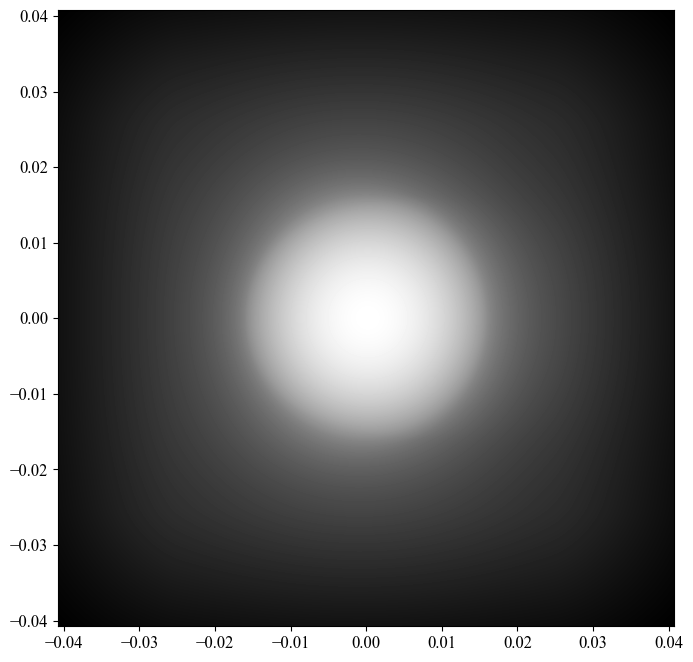

In [375]:
convolved_brightnesses = sim.convolve(source_profile=source_profile)

fig = plt.figure()
ax = fig.add_subplot()
ax.imshow(convolved_brightnesses, origin='lower', extent=[-sim.ang_width/2, sim.ang_width/2, -sim.ang_width/2, sim.ang_width/2], cmap='grey')

plt.show()

Convolving source profile with magnification map: 0.424 seconds


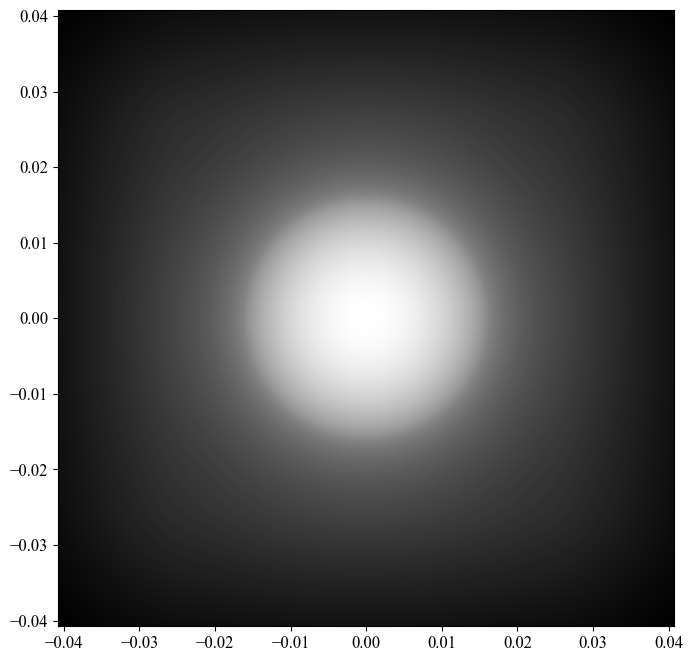

In [376]:
single_convolved_brightnesses = single_sim.convolve(source_profile=source_profile)

fig = plt.figure()
ax = fig.add_subplot()
ax.imshow(single_convolved_brightnesses, origin='lower', extent=[-sim.ang_width/2, sim.ang_width/2, -sim.ang_width/2, sim.ang_width/2], cmap='grey')

plt.show()

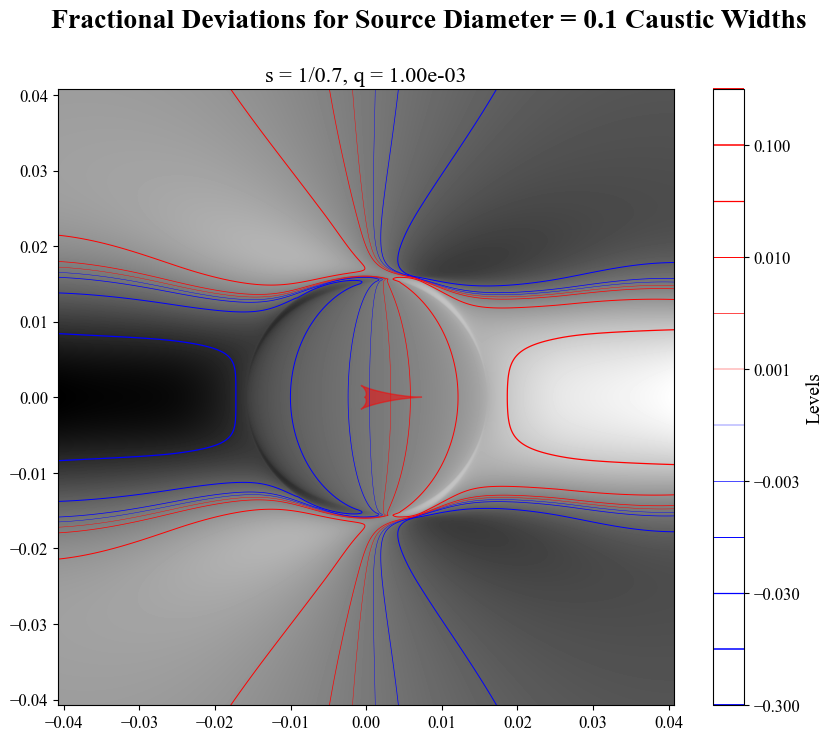

In [377]:
fractional_deviations = (convolved_brightnesses - single_convolved_brightnesses) / single_convolved_brightnesses

fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle(f'Fractional Deviations for Source Diameter = 0.1 Caustic Widths')

ax.set_title(f's = {s_str}, q = {q:.2e}')

for caustic in caustics:
    x = caustic[0] + center_of_mass[0] - desired_offset[0]
    y = caustic[1] + center_of_mass[1] - desired_offset[1]
    points = np.array([x, y]).T
    
    fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Caustics', facecolor='red', alpha=0.5)
    ax.add_patch(fpr)

max_source_patch = patches.Circle((0, 0), max_source_radius, fill=True, edgecolor='black', facecolor='black', alpha=0.5, linestyle='--', label='Max Source Size')

ax.imshow(fractional_deviations, origin='lower', extent=[-sim.ang_width/2, sim.ang_width/2, -sim.ang_width/2, sim.ang_width/2], cmap='grey')
img = ax.contour(fractional_deviations, 
           levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
           colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
           linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
           extent=[-sim.ang_width/2, sim.ang_width/2, -sim.ang_width/2, sim.ang_width/2]
)
plt.colorbar(img, ax=ax, label='Levels')

ax.set_xlim(-sim.ang_width/2, sim.ang_width/2)
ax.set_ylim(-sim.ang_width/2, sim.ang_width/2)
ax.set_aspect('equal')

# ax.add_patch(max_source_patch)

plt.show()